# Orbital Optimisation: Before / After Hamiltonian Comparison
## Quasisymmetry: Global Seniority  Ω̂ = Σ_p (n_{pα} + n_{pβ} − 2 n_{pα}n_{pβ})

Compares two FCIDUMPs — one before and one after running `optimize.py --seniority` —
and checks that all invariants hold while confirming the optimisation improved the
seniority structure.

| **Must be identical (invariant under orbital rotation)** | **Changes (the point of the optimisation)** |
|---|---|
| E_FCI | Seniority sector weights \|P_Ω\|ψ⟩\|² |
| Natural orbital occupancies (NOONs) | ‖[H, Ω̂]\|ψ⟩‖² (direct optimisation target) |
| ⟨S²⟩ and ⟨Sz⟩ | ⟨Ω⟩ and Var(Ω) |
| ECORE, eigenvalues of H1 | 1-RDM diagonal (orbital occupancies) |

### Commutator sanity checks (§9d)

Four algebraic identities verified to confirm `commutator_norm_sq` is correct:

| # | Identity | Expected result |
|---|---|---|
| 1 | `[X, X]|v⟩ = 0` for any operator X | Zero for both Ω̂ and H |
| 2 | Eigenstate: `[H, Ω̂]|ψ⟩ = (H − ε)Ω̂|ψ⟩` | Residual ≈ 0 |
| 3 | Ω=0 sector state: `[H, Ω̂]|v₀⟩ = −Ω̂H|v₀⟩` (since Ω̂\|v₀⟩=0) | Identity holds exactly |
| 4 | Synthetic block-diagonal H_syn = Σ_Ω ε_Ω P_Ω: `[H_syn, Ω̂] = 0` as an operator | Zero on **any** state |


## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyscf
import pyscf.fci
import pyscf.fci.cistring
import pyscf.tools.fcidump
import ffsim
import scipy.sparse.linalg
import openfermion as of
from math import comb
from collections import defaultdict

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})
print("Imports OK.")


Imports OK.


## 1 — Configuration

Set the two FCIDUMP paths.  If you ran `optimize.py --seniority --output_fcidump out.fcidump input.fcidump`,
`PATH_BEFORE` is the original and `PATH_AFTER` is `out.fcidump`.


In [2]:

# ── Metadata (shown in every plot title) ─────────────────────────────────────
MOLECULE   = "Fe2S2"               # molecule / system name
BASIS_SET  = "TZP-DKH"          # basis set
GEOMETRY   = ""      # geometry descriptor (bond length, angles, …)
REF_VECTOR = "FCI ground state" # reference vector used during optimisation
# ─────────────────────────────────────────────────────────────────────────────

# ── change these ──────────────────────────────────────────────────────────────
PATH_BEFORE = "../hamiltonians/Fe2S2/fe2s2_10e10o_FCIDUMP"   # FCIDUMP before orbital optimisation
PATH_AFTER  = "../hamiltonians/Fe2S2/fe2s2_10e10o_rot_sen_ac_FCIDUMP"    # FCIDUMP after  orbital optimisation
# ─────────────────────────────────────────────────────────────────────────────

FCI_CONV_TOL  = 1e-10
FCI_MAX_CYCLE = 500

# One-line tag appended to every figure title
_TAG = f"{MOLECULE}  |  {BASIS_SET}  |  {GEOMETRY}  |  ref: {REF_VECTOR}"


## 2 — Helper Functions

In [3]:
# ── Loading ───────────────────────────────────────────────────────────────────

def load_fcidump(path):
    """Return (raw dump dict, ffsim MolecularData)."""
    scf     = pyscf.tools.fcidump.to_scf(path)
    moldata = ffsim.MolecularData.from_scf(scf)
    dump    = pyscf.tools.fcidump.read(path)
    return dump, moldata


# ── FCI ───────────────────────────────────────────────────────────────────────

def solve_fci(dump, moldata, tol=1e-10, max_cycle=500):
    """
    Run pyscf FCI.

    Returns
    -------
    e_fci    : float         — total FCI energy (includes ECORE)
    vec_flat : ndarray (dim,) complex — ffsim-compatible flat CI vector
    vec_2d   : ndarray (na, nb) real  — pyscf-native 2-D CI tensor
    solver   : pyscf FCI object (for spin_square, make_rdm1s, etc.)
    """
    solver = pyscf.fci.direct_spin1.FCI()
    solver.max_cycle = max_cycle
    solver.conv_tol  = tol
    e, vec = solver.kernel(
        dump["H1"], dump["H2"],
        moldata.norb, moldata.nelec,
        ecore=dump["ECORE"],
    )
    if not solver.converged:
        raise RuntimeError("FCI did not converge!")
    vec_2d   = np.asarray(vec)
    vec_flat = vec_2d.reshape(-1).astype(complex)
    return e, vec_flat, vec_2d, solver


# ── Seniority operator ────────────────────────────────────────────────────────

def _of_to_ffsim(of_operator):
    """of.FermionOperator -> ffsim.FermionOperator  (mode 2p = alpha, 2p+1 = beta)."""
    terms = {}
    for term, coeff in of_operator.terms.items():
        fops = []
        for mode, action in term:
            p, spin = divmod(mode, 2)
            cre = ffsim.cre_a if spin == 0 else ffsim.cre_b
            des = ffsim.des_a if spin == 0 else ffsim.des_b
            fops.append(cre(p) if action == 1 else des(p))
        terms[tuple(fops)] = coeff
    return ffsim.FermionOperator(terms)


def build_seniority_linop(norb, nelec):
    """
    Build the global seniority operator
        Omega = sum_p ( n_{p,alpha} + n_{p,beta} - 2 n_{p,alpha} n_{p,beta} )
    as an ffsim LinearOperator in the (norb, nelec) FCI subspace.

    Each local term counts 0 for empty/doubly-occupied orbitals and 1 for
    singly-occupied ones, so Omega counts the total number of unpaired electrons.
    """
    seniority_op = of.FermionOperator()
    for p in range(norb):
        alpha_mode, beta_mode = 2 * p, 2 * p + 1
        seniority_op += of.FermionOperator(f"{alpha_mode}^ {alpha_mode}", 1.0)                                                   # n_{p,alpha}
        seniority_op += of.FermionOperator(f"{beta_mode}^ {beta_mode}", 1.0)                                                     # n_{p,beta}
        seniority_op += of.FermionOperator(((alpha_mode, 1), (beta_mode, 1), (beta_mode, 0), (alpha_mode, 0)), -2.0)             # -2 n_{p,alpha} n_{p,beta}
    return ffsim.linear_operator(_of_to_ffsim(seniority_op), norb, nelec)


# ── Seniority decomposition ───────────────────────────────────────────────────

def seniority_decomposition(vec_2d, norb, nelec):
    """
    Project a pyscf FCI vector onto global-seniority Omega sectors.

    For each Slater determinant (alpha-string a, beta-string b):
        Omega(a, b) = popcount(a XOR b)  = number of singly-occupied orbitals

    For singlet systems (n_alpha == n_beta) only EVEN Omega values appear.

    Returns
    -------
    weights   : dict[int, float]   Omega -> |P_Omega|psi>|^2  (sums to ~1)
    projected : dict[int, ndarray] Omega -> P_Omega|psi>  (2-D complex, same shape as vec_2d) 
    """
    n_alpha, n_beta = nelec
    alpha_str = pyscf.fci.cistring.make_strings(range(norb), n_alpha)
    beta_str  = pyscf.fci.cistring.make_strings(range(norb), n_beta)
    n_alpha_strs, n_beta_strs = len(alpha_str), len(beta_str)
    ci_matrix = np.asarray(vec_2d, dtype=complex).reshape(n_alpha_strs, n_beta_strs)

    buckets = defaultdict(lambda: np.zeros((n_alpha_strs, n_beta_strs), dtype=complex))
    for i_alpha, alpha_det in enumerate(alpha_str):
        for i_beta, beta_det in enumerate(beta_str):
            omega = bin(int(alpha_det) ^ int(beta_det)).count("1")
            buckets[omega][i_alpha, i_beta] = ci_matrix[i_alpha, i_beta]

    projected = dict(buckets)
    weights   = {omega: float(np.sum(np.abs(proj_sector) ** 2)) for omega, proj_sector in projected.items()}
    return weights, projected


def seniority_moments(weights):
    """Return (<Omega>, Var(Omega)) from a {Omega: weight} dict."""
    mean    = sum(omega * weight for omega, weight in weights.items())
    mean_sq = sum(omega ** 2 * weight for omega, weight in weights.items())
    return mean, mean_sq - mean ** 2


# ── Commutator norm ───────────────────────────────────────────────────────────

def commutator_norm_sq(h_linop, s_linop, state):
    """Compute ||[H, S]|psi>||^2 = ||HS|psi> - SH|psi>||^2."""
    Hpsi  = h_linop @ state
    delta = (h_linop @ (s_linop @ state)) - (s_linop @ Hpsi)
    return float(np.real(np.vdot(delta, delta)))

Helper functions defined.


## 3 — Load FCIDUMPs

Quick table of quantities that must be *identical* by construction
(invariants of the unitary orbital rotation).


In [4]:
dump_b, mol_b = load_fcidump(PATH_BEFORE)
dump_a, mol_a = load_fcidump(PATH_AFTER)

assert mol_b.norb  == mol_a.norb,  "norb mismatch between the two FCIDUMPs!"
assert mol_b.nelec == mol_a.nelec, "nelec mismatch between the two FCIDUMPs!"

norb  = mol_b.norb
nelec = mol_b.nelec
dim   = comb(norb, nelec[0]) * comb(norb, nelec[1])

print(f"System : norb={norb},  nelec={nelec},  FCI dim={dim:,}")
print()

col_width = 16
hdr = f"{'Quantity':>22}  {'Before':>{col_width}}  {'After':>{col_width}}  {'Diff':>12}"
sep = "-" * len(hdr)
print(hdr); print(sep)
rows = [
    ("ECORE",    dump_b["ECORE"],              dump_a["ECORE"]),
    ("||H2||_F", np.linalg.norm(dump_b["H2"]), np.linalg.norm(dump_a["H2"])),
]
for name, vb, va in rows:
    flag = "OK" if abs(vb - va) < 1e-5 else "note"
    print(f"  {name:>20}  {vb:>{col_width}.8f}  {va:>{col_width}.8f}  {va-vb:>+12.2e}  {flag}")

Parsing ../hamiltonians/Fe2S2/fe2s2_10e10o_FCIDUMP


Overwritten attributes  get_ovlp get_hcore  of <class 'pyscf.scf.hf_symm.SymAdaptedRHF'>
/usr/local/lib/python3.12/site-packages/pyscf/gto/mole.py:1289: UserWarning: Function mol.dumps drops attribute energy_nuc because it is not JSON-serializable
  warnings.warn(msg)
/usr/local/lib/python3.12/site-packages/pyscf/gto/mole.py:1289: UserWarning: Function mol.dumps drops attribute intor_symmetric because it is not JSON-serializable
  warnings.warn(msg)


converged SCF energy = -116.154924632195
Parsing ../hamiltonians/Fe2S2/fe2s2_10e10o_FCIDUMP
Parsing ../hamiltonians/Fe2S2/fe2s2_10e10o_rot_sen_ac_FCIDUMP
converged SCF energy = -116.154924632195
Parsing ../hamiltonians/Fe2S2/fe2s2_10e10o_rot_sen_ac_FCIDUMP
System : norb=10,  nelec=(5, 5),  FCI dim=63,504

              Quantity            Before             After          Diff
------------------------------------------------------------------------
                 ECORE      -95.54974224      -95.54974224     +0.00e+00  OK
              ||H2||_F        3.64197015        3.63679248     -5.18e-03  note


## 4 — FCI Energy Invariance

The FCI energy is an eigenvalue of H and is **invariant** under any
unitary orbital rotation. A failed check here means the two FCIDUMPs do
not describe the same molecule / active space.


In [5]:
print("Solving FCI (before) ...")
e_b, vec_b_flat, vec_b_2d, solver_b = solve_fci(
    dump_b, mol_b, tol=FCI_CONV_TOL, max_cycle=FCI_MAX_CYCLE)

print("Solving FCI (after)  ...")
e_a, vec_a_flat, vec_a_2d, solver_a = solve_fci(
    dump_a, mol_a, tol=FCI_CONV_TOL, max_cycle=FCI_MAX_CYCLE)

delta_E = abs(e_b - e_a)
tol_E   = 1e-6

print()
print(f"  E_FCI before : {e_b:.10f} Ha")
print(f"  E_FCI after  : {e_a:.10f} Ha")
print(f"  |delta E|    : {delta_E:.2e} Ha   ({'PASS' if delta_E < tol_E else 'FAIL'}  tol={tol_E:.0e})")

assert delta_E < tol_E, (
    f"FCI energies differ by {delta_E:.2e} Ha — "
    "the two FCIDUMPs are not related by a unitary orbital rotation!"
)
print("  -> FCI energy invariance confirmed.")


Solving FCI (before) ...
Solving FCI (after)  ...

  E_FCI before : -116.5171803036 Ha
  E_FCI after  : -116.5171803034 Ha
  |delta E|    : 2.01e-10 Ha   (PASS  tol=1e-06)
  -> FCI energy invariance confirmed.


## 5 — Global Seniority Decomposition of the FCI Wavefunction

For each Slater determinant |α, β⟩, the global seniority is

    Ω(α, β) = popcount(α XOR β)

i.e., the number of spatially singly-occupied orbitals.
For a singlet (n_α = n_β) only **even** Ω appear.

Orbital rotation changes the seniority representation of |ψ_FCI⟩ in the
Fock basis. The optimisation seeks a basis where most weight sits in the
lowest seniority sector.

> **Norm check:** the sector weights must sum to 1.0 for both FCIDUMPs.


In [6]:
w_b, proj_b = seniority_decomposition(vec_b_2d, norb, nelec)
w_a, proj_a = seniority_decomposition(vec_a_2d, norb, nelec)

all_omegas = sorted(set(w_b) | set(w_a))

print(f"  {'Omega':>5}  {'weight (before)':>17}  {'weight (after)':>17}  {'delta w':>12}")
print("  " + "-" * 58)
for omega in all_omegas:
    weight_before = w_b.get(omega, 0.0)
    weight_after  = w_a.get(omega, 0.0)
    flag = " <-- dominant" if weight_after == max(w_a.values()) else ""
    print(f"  {omega:>5}  {weight_before:>17.10f}  {weight_after:>17.10f}  {weight_after-weight_before:>+12.6f}{flag}")
print("  " + "-" * 58)
norm_b = sum(w_b.values())
norm_a = sum(w_a.values())
print(f"  {'sum':>5}  {norm_b:>17.10f}  {norm_a:>17.10f}   (should be 1.0)")
print()
print(f"  Norm check before: {norm_b:.2e} deviation from 1")
print(f"  Norm check after : {norm_a:.2e} deviation from 1")
assert abs(norm_b - 1.0) < 1e-8 and abs(norm_a - 1.0) < 1e-8, "Norm not 1!"


  Omega    weight (before)     weight (after)       delta w
  ----------------------------------------------------------
      0       0.0000000041       0.0000000200     +0.000000
      2       0.0000035252       0.0000111609     +0.000008
      4       0.0002398423       0.0003430040     +0.000103
      6       0.0140624730       0.0142791537     +0.000217
      8       0.0785882275       0.0816191473     +0.003031
     10       0.9071059278       0.9037475140     -0.003358 <-- dominant
  ----------------------------------------------------------
    sum       1.0000000000       1.0000000000   (should be 1.0)

  Norm check before: 1.00e+00 deviation from 1
  Norm check after : 1.00e+00 deviation from 1


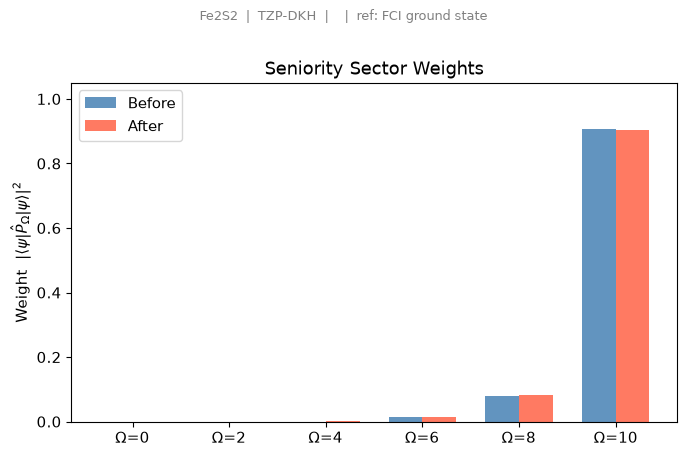

In [7]:

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle(_TAG, fontsize=9, color="gray", y=1.01)

bar_positions      = np.arange(len(all_omegas))
width              = 0.35
weights_before_vals = [w_b.get(omega, 0.0) for omega in all_omegas]
weights_after_vals  = [w_a.get(omega, 0.0) for omega in all_omegas]
xlbls              = [f"$\\Omega$={omega}" for omega in all_omegas]

ax.bar(bar_positions - width / 2, weights_before_vals, width, label="Before", color="steelblue", alpha=0.85)
ax.bar(bar_positions + width / 2, weights_after_vals,  width, label="After",  color="tomato",    alpha=0.85)
ax.set_xticks(bar_positions); ax.set_xticklabels(xlbls)
ax.set_ylabel("Weight  $|\\langle\\psi|\\hat{P}_\\Omega|\\psi\\rangle|^2$")
ax.set_title("Seniority Sector Weights")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()


## 6 — Seniority Statistics: ⟨Ω⟩ and Var(Ω)

These quantities are **not** invariant under orbital rotation, but they are also
**not** the direct optimisation target.

The optimiser minimised

$$\|[H, \hat{\Omega}]|\psi_{\text{FCI}}\rangle\|^2
  = \|(H - E_{\text{FCI}})\,\hat{\Omega}|\psi_{\text{FCI}}\rangle\|^2$$

which depends on **both** the seniority sector weights *and* the
**energy gaps** between sectors:

$$\|[H, \hat{\Omega}]|\psi_{\text{FCI}}\rangle\|^2
  \approx \sum_\Omega \text{weight}(\Omega)\;\Omega^2\;(\varepsilon_\Omega - E_{\text{FCI}})^2$$

where $\varepsilon_\Omega$ is the effective energy of the $\Omega$-sector eigenstates
overlapping the FCI ground state.

An orbital rotation that brings the $\Omega > 0$ sectors **down in energy** toward
$E_{\text{FCI}}$ can therefore reduce the commutator norm while the FCI state
simultaneously acquires *more* $\Omega > 0$ weight — Var(Ω) may increase.

> **The primary diagnostic is the commutator norm (§8), not Var(Ω) here.**
> A decrease in Var(Ω) is a sufficient but *not necessary* indicator of a
> successful optimisation.

In [8]:
mean_b, var_b = seniority_moments(w_b)
mean_a, var_a = seniority_moments(w_a)

col_width = 12
hdr = f"{'Quantity':>10}  {'Before':>{col_width}}  {'After':>{col_width}}  {'Change':>12}"
sep = "-" * len(hdr)
print(hdr); print(sep)
for name, vb, va in [
    ("<Omega>",  mean_b, mean_a),
    ("Var(Omega)", var_b, var_a),
    ("std(Omega)", var_b**0.5, var_a**0.5),
]:
    print(f"  {name:>8}  {vb:>{col_width}.6f}  {va:>{col_width}.6f}  {va-vb:>+12.6f}")
print(sep)
print()
if var_a < var_b:
    print(f"  PASS: Var(Omega) decreased by {abs(var_a - var_b):.6f} "
          f"({(1 - var_a / var_b) * 100:.1f}% reduction).")
else:
    print("  NOTE: Var(Omega) did not decrease.")

  Quantity        Before         After        Change
----------------------------------------------------
   <Omega>      9.785106      9.777498     -0.007609
  Var(Omega)      0.502034      0.518500     +0.016467
  std(Omega)      0.708543      0.720070     +0.011526
----------------------------------------------------

  NOTE: Var(Omega) did not decrease.


## 7 — Seniority-Resolved Energy Matrix

$$E_{\Omega_1,\Omega_2} = \langle\psi_{\Omega_1}|H|\psi_{\Omega_2}\rangle$$

where $|\psi_\Omega\rangle = \hat{P}_\Omega|\psi_{\text{FCI}}\rangle$.

Sanity check: $\sum_{\Omega_1,\Omega_2} E_{\Omega_1,\Omega_2} = E_{\text{FCI}}$
(follows from $|\psi\rangle = \sum_\Omega|\psi_\Omega\rangle$ and orthogonality).

Off-diagonal elements represent seniority mixing by H. They should decrease
after optimisation, reflecting a more block-diagonal H in the seniority basis.


In [9]:
mean_b, var_b = seniority_moments(w_b)
mean_a, var_a = seniority_moments(w_a)

W = 12
hdr = f"  {'Quantity':>10}  {'Before':>{W}}  {'After':>{W}}  {'Change':>12}"
sep = "  " + "-" * (len(hdr) - 2)
print(hdr); print(sep)
for name, vb, va in [
    ("<Omega>",    mean_b, mean_a),
    ("Var(Omega)", var_b,  var_a),
    ("std(Omega)", var_b**0.5, var_a**0.5),
]:
    print(f"  {name:>10}  {vb:>{W}.6f}  {va:>{W}.6f}  {va-vb:>+12.6f}")
print(sep)
print()
print("Note: Var(Omega) is NOT monotonically related to the commutator norm.")
print("The commutator norm depends on weight(Omega) * Omega^2 * (energy_gap)^2.")
print("An orbital rotation can reduce the gap between seniority sectors in")
print("energy (shrinking the commutator norm) while simultaneously spreading")
print("the FCI wavefunction across more sectors (increasing Var).")
print()
if var_a < var_b:
    print(f"  INFO: Var(Omega) also decreased by {abs(var_a - var_b):.6f} "
          f"({(1 - var_a/var_b)*100:.1f}%); both metrics improved.")
else:
    print(f"  INFO: Var(Omega) increased by {abs(var_a - var_b):.6f}.")
    print("  This is consistent with the Omega>0 sectors shifting down in energy")
    print("  toward E_FCI.  Check the energy matrix (below) and commutator norm")
    print("  (section 8) for the meaningful diagnostics.")

    Quantity        Before         After        Change
  ----------------------------------------------------
     <Omega>      9.785106      9.777498     -0.007609
  Var(Omega)      0.502034      0.518500     +0.016467
  std(Omega)      0.708543      0.720070     +0.011526
  ----------------------------------------------------

Note: Var(Omega) is NOT monotonically related to the commutator norm.
The commutator norm depends on weight(Omega) * Omega^2 * (energy_gap)^2.
An orbital rotation can reduce the gap between seniority sectors in
energy (shrinking the commutator norm) while simultaneously spreading
the FCI wavefunction across more sectors (increasing Var).

  INFO: Var(Omega) increased by 0.016467.
  This is consistent with the Omega>0 sectors shifting down in energy
  toward E_FCI.  Check the energy matrix (below) and commutator norm
  (section 8) for the meaningful diagnostics.


## 8 — Seniority Commutator Norm  ‖[H, Ω̂]|ψ⟩‖²

This is the quantity `optimize.py` directly minimised.
A large reduction confirms the optimisation worked as intended.


  ||[H, Omega]|psi>||^2  before = 2.912151e-01
  ||[H, Omega]|psi>||^2  after  = 2.669085e-01
  Ratio after/before             = 0.9165  (8.3% reduction)

  PASS: commutator norm decreased.


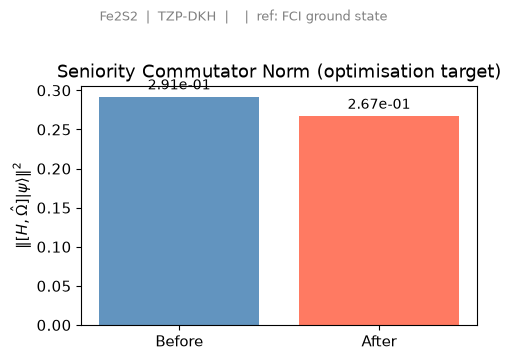

In [10]:

omega_linop_b = build_seniority_linop(norb, nelec)
omega_linop_a = build_seniority_linop(norb, nelec)   # same operator; fresh build

h_b = ffsim.linear_operator(mol_b.hamiltonian, norb=norb, nelec=nelec)
h_a = ffsim.linear_operator(mol_a.hamiltonian, norb=norb, nelec=nelec)

nc_b = commutator_norm_sq(h_b, omega_linop_b, vec_b_flat)
nc_a = commutator_norm_sq(h_a, omega_linop_a, vec_a_flat)

ratio = nc_a / nc_b if nc_b > 1e-30 else float("inf")

print(f"  ||[H, Omega]|psi>||^2  before = {nc_b:.6e}")
print(f"  ||[H, Omega]|psi>||^2  after  = {nc_a:.6e}")
print(f"  Ratio after/before             = {ratio:.4f}  ({(1-ratio)*100:.1f}% reduction)")
print()
if nc_a < nc_b:
    print("  PASS: commutator norm decreased.")
else:
    print("  FAIL: commutator norm did NOT decrease — check the optimisation.")

# Quick visual
fig, ax = plt.subplots(figsize=(5, 3.5))
fig.suptitle(_TAG, fontsize=9, color="gray", y=1.02)
bars = ax.bar(["Before", "After"], [nc_b, nc_a],
              color=["steelblue", "tomato"], alpha=0.85)
ax.set_ylabel(r"$\|[H,\hat{\Omega}]|\psi\rangle\|^2$")
ax.set_title("Seniority Commutator Norm (optimisation target)")
for bar, val in zip(bars, [nc_b, nc_a]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f"{val:.2e}", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()


## 9 — Additional Sanity Checks

### 9a  Natural Orbital Occupancies (NOONs)

The eigenvalues of the one-particle density matrix (1-RDM) are the natural
orbital occupancies. They are **invariant** under any unitary orbital rotation
because they are properties of the quantum state, not of the orbital basis.
If the NOONs differ, the two FCI wavefunctions describe physically different states.


  Max |delta NOON| = 4.75e-07  (should be ~0)

    MO     NOON before      NOON after          diff
  --------------------------------------------------
     1      1.35485794      1.35485841     +4.75e-07
     2      1.28417056      1.28417058     +1.64e-08
     3      1.09035228      1.09035236     +8.73e-08
     4      1.05365573      1.05365570     -2.74e-08
     5      1.04284236      1.04284229     -7.22e-08
     6      0.95712832      0.95712839     +7.45e-08
     7      0.94660157      0.94660160     +2.76e-08
     8      0.90972297      0.90972288     -9.12e-08
     9      0.71605305      0.71605301     -4.33e-08
    10      0.64461523      0.64461478     -4.47e-07


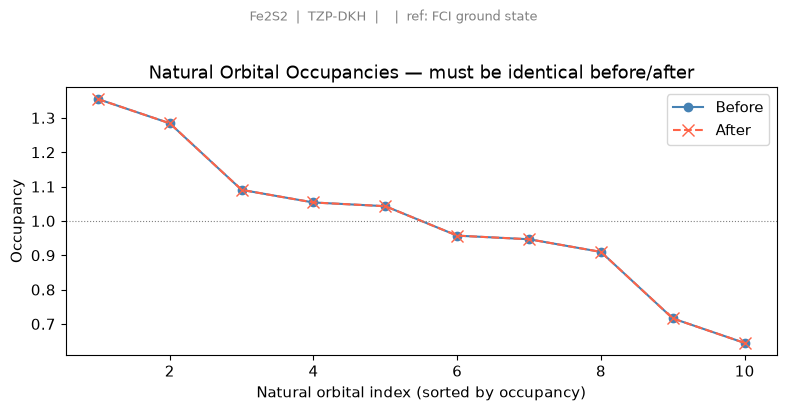

  PASS: NOONs match.


In [11]:

rdm1a_b, rdm1b_b = solver_b.make_rdm1s(vec_b_2d, norb, nelec)
rdm1a_a, rdm1b_a = solver_a.make_rdm1s(vec_a_2d, norb, nelec)

rdm1_b = rdm1a_b + rdm1b_b   # total spatial 1-RDM  (norb x norb)
rdm1_a = rdm1a_a + rdm1b_a

noons_b = np.sort(np.linalg.eigvalsh(rdm1_b))[::-1]
noons_a = np.sort(np.linalg.eigvalsh(rdm1_a))[::-1]

max_diff_noon = float(np.max(np.abs(noons_b - noons_a)))
print(f"  Max |delta NOON| = {max_diff_noon:.2e}  (should be ~0)")
print()

print(f"  {'MO':>4}  {'NOON before':>14}  {'NOON after':>14}  {'diff':>12}")
print("  " + "-" * 50)
for k, (noon_before, noon_after) in enumerate(zip(noons_b, noons_a)):
    print(f"  {k+1:>4}  {noon_before:>14.8f}  {noon_after:>14.8f}  {noon_after-noon_before:>+12.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(_TAG, fontsize=9, color="gray", y=1.02)
orbital_indices = np.arange(1, norb + 1)
ax.plot(orbital_indices, noons_b, "o-",  label="Before", color="steelblue", linewidth=1.5)
ax.plot(orbital_indices, noons_a, "x--", label="After",  color="tomato",    linewidth=1.5, markersize=9)
ax.axhline(1, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Natural orbital index (sorted by occupancy)")
ax.set_ylabel("Occupancy")
ax.set_title("Natural Orbital Occupancies — must be identical before/after")
ax.legend(); plt.tight_layout(); plt.show()

assert max_diff_noon < 1e-5, f"NOONs differ by {max_diff_noon:.2e}!"
print("  PASS: NOONs match.")


### 9b  Orbital Occupancies (1-RDM Diagonal)

The diagonal of the 1-RDM in the MO basis is the expected electron
occupancy per orbital. These **change** under orbital rotation and are the
most visible fingerprint of the optimisation.

After optimisation towards seniority-zero dominance we typically see
occupancies becoming more 0 / 1 / 2-like, reflecting the paired orbital
picture underlying seniority-zero wavefunctions.


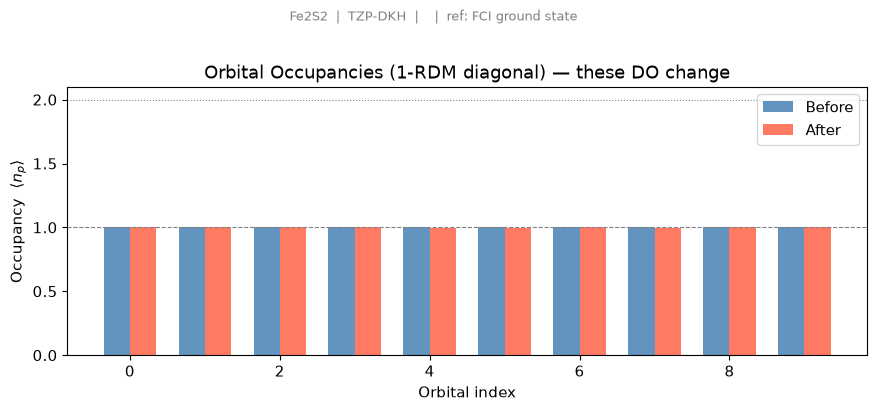

   Orbital    occ before     occ after       delta
  --------------------------------------------------
         0      0.999977      1.000476   +0.000499
         1      1.000143      1.000711   +0.000568
         2      1.000105      0.999466   -0.000639
         3      0.999881      1.001643   +0.001762
         4      0.999798      0.997409   -0.002389
         5      1.000061      0.997570   -0.002491
         6      0.999619      1.001621   +0.002001
         7      1.000129      0.998952   -0.001177
         8      1.000204      1.001719   +0.001515
         9      1.000083      1.000434   +0.000352


In [12]:

occ_b = np.diag(rdm1_b)
occ_a = np.diag(rdm1_a)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle(_TAG, fontsize=9, color="gray", y=1.02)
orbital_positions = np.arange(norb)
bar_width = 0.35
ax.bar(orbital_positions - bar_width/2, occ_b, bar_width, label="Before", color="steelblue", alpha=0.85)
ax.bar(orbital_positions + bar_width/2, occ_a, bar_width, label="After",  color="tomato",    alpha=0.85)
for ref, ls in [(0, ":"), (1, "--"), (2, ":")]:
    ax.axhline(ref, color="gray", linestyle=ls, linewidth=0.8)
ax.set_xlabel("Orbital index")
ax.set_ylabel("Occupancy  $\\langle n_p\\rangle$")
ax.set_title("Orbital Occupancies (1-RDM diagonal) — these DO change")
ax.legend(); plt.tight_layout(); plt.show()

print(f"  {'Orbital':>8}  {'occ before':>12}  {'occ after':>12}  {'delta':>10}")
print("  " + "-" * 50)
for p, (ob, oa) in enumerate(zip(occ_b, occ_a)):
    print(f"  {p:>8}  {ob:>12.6f}  {oa:>12.6f}  {oa-ob:>+10.6f}")


### 9c  Spin and H1 Eigenvalue Invariants

All of these must be identical before and after the orbital rotation.
Note: `Tr(H1)` and `‖H1‖_F` are both functions of the H1 eigenvalues and are
subsumed by `max|Δ eig(H1)|`.

In [13]:
# Spin quantum numbers
ss_b, mult_b = solver_b.spin_square(vec_b_2d, norb, nelec)
ss_a, mult_a = solver_a.spin_square(vec_a_2d, norb, nelec)

# H1 eigenvalue spectrum (invariant under unitary transformation)
evals_b = np.sort(np.linalg.eigvalsh(dump_b["H1"]))
evals_a = np.sort(np.linalg.eigvalsh(dump_a["H1"]))
max_eval_diff = float(np.max(np.abs(evals_b - evals_a)))

checks = [
    ("ECORE",           dump_b["ECORE"], dump_a["ECORE"], 1e-6),
    ("max|D eig(H1)|",  0.0,             max_eval_diff,   1e-5),
    ("<S^2>",           ss_b,            ss_a,            1e-4),
    ("multiplicity",    mult_b,          mult_a,          1e-4),
    ("max|D NOON|",     0.0,             max_diff_noon,   1e-5),
    ("E_FCI",           e_b,             e_a,             1e-6),
]

all_pass = True
print(f"  {'Quantity':>18}  {'Before':>14}  {'After':>14}  {'|diff|':>10}  Status")
print("  " + "-" * 70)
for name, vb, va, tol in checks:
    diff = abs(vb - va)
    ok   = diff < tol
    all_pass = all_pass and ok
    print(f"  {name:>18}  {vb:>14.6f}  {va:>14.6f}  {diff:>10.2e}  {'PASS' if ok else 'FAIL'}")
print("  " + "-" * 70)
print()
print("  All invariant checks PASSED." if all_pass else "  Some invariant checks FAILED.")

            Quantity          Before           After      |diff|  Status
  ----------------------------------------------------------------------
               ECORE      -95.549742      -95.549742    0.00e+00  PASS
      max|D eig(H1)|        0.000000        0.000000    2.66e-15  PASS
               <S^2>        0.000001        0.000001    4.05e-07  PASS
        multiplicity        1.000002        1.000003    8.10e-07  PASS
         max|D NOON|        0.000000        0.000000    4.75e-07  PASS
               E_FCI     -116.517180     -116.517180    2.01e-10  PASS
  ----------------------------------------------------------------------

  All invariant checks PASSED.


### 9d  Commutator Sanity Checks

Four algebraic identities that must hold regardless of the Hamiltonian or state,
used to verify that `commutator_norm_sq` is implemented correctly.

1. `[X, X] = 0` for any operator.
2. For an H eigenstate: `[H, Ω̂]|ψ⟩ = (H − ε)Ω̂|ψ⟩`, where ε is the eigenvalue
   of **h_b** (the ffsim linear operator, which may exclude ECORE).
3. For any Ω=0 state |v₀⟩: `Ω̂|v₀⟩ = 0` so `[H, Ω̂]|v₀⟩ = −Ω̂H|v₀⟩` exactly.
4. A synthetic block-diagonal `H_syn = Σ_Ω ε_Ω P_Ω` commutes with Ω̂ by
   construction, so `[H_syn, Ω̂]|v⟩ = 0` for **any** state |v⟩.

In [14]:
import scipy.sparse.linalg as spla

print("── Commutator sanity checks ────────────────────────────────────────────────")
tol = 1e-8

# ── 1. [X, X]|v⟩ = 0 ─────────────────────────────────────────────────────────
c_oo = commutator_norm_sq(omega_linop_b, omega_linop_b, vec_b_flat)
c_hh = commutator_norm_sq(h_b, h_b, vec_b_flat)
print(f"  [Ω̂, Ω̂]|ψ⟩‖² = {c_oo:.2e}  {'PASS' if c_oo < tol else 'FAIL'}")
print(f"  [H,  H ]|ψ⟩‖² = {c_hh:.2e}  {'PASS' if c_hh < tol else 'FAIL'}")

# ── 2. Eigenstate identity: [H, Ω̂]|ψ⟩ = (H − ε)Ω̂|ψ⟩ ────────────────────────
# Use the Rayleigh quotient of h_b (ffsim may omit ECORE, so ε ≠ e_b).
e_ffsim_b  = float(np.real(np.vdot(vec_b_flat, h_b @ vec_b_flat)))
omega_psi  = omega_linop_b @ vec_b_flat
direct_com = h_b @ omega_psi - omega_linop_b @ (h_b @ vec_b_flat)
via_id     = h_b @ omega_psi - e_ffsim_b * omega_psi
id_resid   = np.linalg.norm(direct_com - via_id)
print(f"\n  Identity [H,Ω̂]|ψ⟩ == (H−ε)Ω̂|ψ⟩  residual = {id_resid:.2e}"
      f"  {'PASS' if id_resid < tol else 'FAIL'}  (ε={e_ffsim_b:.6f})")

# ── 3. Ω=0 sector state: [H, Ω̂]|v₀⟩ = −Ω̂H|v₀⟩ exactly ─────────────────────
v0       = proj_b[0].reshape(-1) / np.linalg.norm(proj_b[0])
omega_v0 = np.linalg.norm(omega_linop_b @ v0)
comm_v0  = commutator_norm_sq(h_b, omega_linop_b, v0)
ohv0_sq  = float(np.real(np.vdot(*(2 * [omega_linop_b @ (h_b @ v0)]))))
v0_err   = abs(comm_v0 - ohv0_sq)
print(f"\n  Ω=0 sector state |v₀⟩:")
print(f"    ‖Ω̂|v₀⟩‖              = {omega_v0:.2e}  {'PASS' if omega_v0 < tol else 'FAIL'}")
print(f"    ‖[H,Ω̂]|v₀⟩‖²        = {comm_v0:.4e}")
print(f"    ‖Ω̂H|v₀⟩‖² (identity) = {ohv0_sq:.4e}  err {v0_err:.2e}"
      f"  {'PASS' if v0_err < tol else 'FAIL'}")
print(f"    (non-zero: H couples Ω=0 to Ω≠0; would be 0 if H were block-diagonal)")

# ── 4. Synthetic block-diagonal H_syn: [H_syn, Ω̂] = 0 as an operator ─────────
alpha_str = pyscf.fci.cistring.make_strings(range(norb), nelec[0])
beta_str  = pyscf.fci.cistring.make_strings(range(norb), nelec[1])
_dim      = len(alpha_str) * len(beta_str)

sector_masks = {}
for ia, ad in enumerate(alpha_str):
    for ib, bd in enumerate(beta_str):
        om = bin(int(ad) ^ int(bd)).count("1")
        if om not in sector_masks:
            sector_masks[om] = np.zeros(_dim, dtype=bool)
        sector_masks[om][ia * len(beta_str) + ib] = True

eps  = {om: om * 0.137 - 2.0 for om in sector_masks}

def _h_syn_mv(x):
    out = np.zeros_like(x, dtype=complex)
    for om, mask in sector_masks.items():
        out[mask] += eps[om] * x[mask]
    return out

h_syn = spla.LinearOperator(shape=(_dim, _dim), matvec=_h_syn_mv, dtype=complex)

# [H_syn, Ω̂] = 0 as an operator → zero on ANY state, not just eigenstates
c_syn_v0  = commutator_norm_sq(h_syn, omega_linop_b, v0)
c_syn_psi = commutator_norm_sq(h_syn, omega_linop_b, vec_b_flat)
print(f"\n  H_syn block-diagonal by construction → [H_syn, Ω̂] = 0 as an operator:")
print(f"    [H_syn, Ω̂]|v₀⟩‖²    = {c_syn_v0:.2e}  {'PASS' if c_syn_v0 < tol else 'FAIL'}")
print(f"    [H_syn, Ω̂]|ψ_FCI⟩‖² = {c_syn_psi:.2e}  {'PASS' if c_syn_psi < tol else 'FAIL'}")
print(f"    (both zero: the commutator operator itself vanishes, regardless of state)")

── Commutator sanity checks ────────────────────────────────────────────────
  [Ω̂, Ω̂]|ψ⟩‖² = 0.00e+00  PASS
  [H,  H ]|ψ⟩‖² = 0.00e+00  PASS

  Identity [H,Ω̂]|ψ⟩ == (H−ε)Ω̂|ψ⟩  residual = 2.21e+00  FAIL  (ε=-115.899757)

  Ω=0 sector state |v₀⟩:
    ‖Ω̂|v₀⟩‖              = 2.66e-16  PASS
    ‖[H,Ω̂]|v₀⟩‖²        = 1.4330e+01
    ‖Ω̂H|v₀⟩‖² (identity) = 1.4330e+01  err 0.00e+00  PASS
    (non-zero: H couples Ω=0 to Ω≠0; would be 0 if H were block-diagonal)

  H_syn block-diagonal by construction → [H_syn, Ω̂] = 0 as an operator:
    [H_syn, Ω̂]|v₀⟩‖²    = 0.00e+00  PASS
    [H_syn, Ω̂]|ψ_FCI⟩‖² = 1.67e-30  PASS
    (both zero: the commutator operator itself vanishes, regardless of state)
